# 使用VGG測試深度網路的梯度消失問題

概念:訓練深層網路時，每一層的輸入分布會隨著前面層的參數更新而不斷改變，這個現象稱為 Internal Covariate Shift

In [31]:
#匯入套件
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 1.建立可調層數的深層網路

default是30層

In [32]:
def make_deep_net(num_layers=30, activation='relu', hidden=256, use_bn=False):
    act_fn = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid}[activation] #可選nn.relu 或是 nn.sigmoid

    def block():
        if use_bn:
            return [nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), act_fn()] #加入batchnormalization
        else:
            return [nn.Linear(hidden, hidden), act_fn()]

    layers = [nn.Flatten(), nn.Linear(3*32*32, hidden), act_fn()]
    for _ in range(num_layers - 2):
        layers += block()
    layers += [nn.Linear(hidden, 10)]
    return nn.Sequential(*layers)
# 30 Layer Example
# flatten -> Linear (1)
# Linear -> relu (28)
# Linear -> 10 classes (1)

## 2.收集每個 Linear 層的梯度 norm

In [33]:
def collect_gradients(num_layers=30, activation='relu',use_bn=False):
    model = make_deep_net(num_layers, activation, use_bn=use_bn) #建立model
    x      = torch.randn(8, 3, 32, 32) #模擬數據特徵
    target = torch.randint(0, 10, (8,)) #模擬數據output
    loss   = nn.CrossEntropyLoss()(model(x), target)
    loss.backward()

    norms, names = [], []
    idx = 1
    for m in model.modules():
        if isinstance(m, nn.Linear) and m.weight.grad is not None: #m.weight.grad 是 loss.backward算出來的梯度
            norms.append(m.weight.grad.norm().item()) #紀錄該層的gradient，用平方和相加(nrom)。 item取締一個0維度data
            names.append(f'L{idx}') #紀錄層數
            idx += 1
    return names, norms

## 3.繪圖（並排 + 比值折線）

In [34]:
def plot(num_layers=30):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Gradient Vanishing — {num_layers}-layer Network', fontsize=13, fontweight='bold')

    configs = [
        ('sigmoid', '#E24B4A', 'Sigmoid', False), #組一:sigmoid 
        ('relu',    '#1D9E75', 'ReLU', False), #組二:relu
        ('relu',  "#1D2A9E", 'ReLU & BN_on', True), #組三:relu + bn
    ]
    all_norms = {}

    for ax, (act, color, label, bn) in zip(axes[:3], configs[:3]): #畫圖及收集梯度
        names, norms = collect_gradients(num_layers, act, bn)
        all_norms[label] = norms  

        ax.bar(range(len(norms)), norms, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.set_yscale('log')
        ax.set_title(label, fontsize=12, color=color, fontweight='bold')
        ax.set_xlabel('Layer index (0 = input side)')
        ax.set_ylabel('Gradient L2 Norm')
        ax.set_xticks(range(0, len(names), max(1, len(names)//8)))
        ax.set_xticklabels(names[::max(1, len(names)//8)], fontsize=8)
        ax.grid(axis='y', alpha=0.25, linestyle='--')

        ratio = max(norms) / (min(norms) + 1e-30)
        ax.text(0.97, 0.97, f'ratio: {ratio:.1e}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    
    # 三張圖統一 Y 軸範圍，方便直接對比
    all_vals = [v for norms in all_norms.values() for v in norms if v > 0]
    ymin, ymax = min(all_vals) * 0.5, max(all_vals) * 2
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.savefig(r'.\vgg_gradient_deep.png', dpi=150, bbox_inches='tight')
    print("圖表已儲存：vgg_gradient_deep.png")
    plt.show()

## 4.用不同層數比較消失速度

In [35]:
def compare_depths(depths=[10, 20, 30, 50]):
    print(f"\n{'Depth':<8} {'Act':<10} {'Max Grad':>12} {'Min Grad':>12} {'Ratio':>12}")
    print('-' * 58)
    for d in depths:
        for act in ['sigmoid', 'relu']:
            _, norms = collect_gradients(d, act, False)
            mx, mn = max(norms), min(norms)
            ratio  = mx / (mn + 1e-30)
            flag   = ' ⚠️' if act == 'sigmoid' and ratio > 1e6 else ''
            print(f"{d:<8} {act:<10} {mx:>12.3e} {mn:>12.3e} {ratio:>12.2e}{flag}")
        print()

## 5.主程式


Depth    Act            Max Grad     Min Grad        Ratio
----------------------------------------------------------
10       sigmoid       3.364e+00    4.404e-07     7.64e+06 ⚠️
10       relu          1.788e-01    1.541e-03     1.16e+02

20       sigmoid       3.615e+00    1.095e-15     3.30e+15 ⚠️
20       relu          1.255e-01    1.565e-07     8.02e+05

30       sigmoid       3.036e+00    0.000e+00     3.04e+30 ⚠️
30       relu          1.737e-01    3.002e-11     5.78e+09

50       sigmoid       2.803e+00    0.000e+00     2.80e+30 ⚠️
50       relu          1.713e-01    6.194e-19     2.77e+17

圖表已儲存：vgg_gradient_deep.png


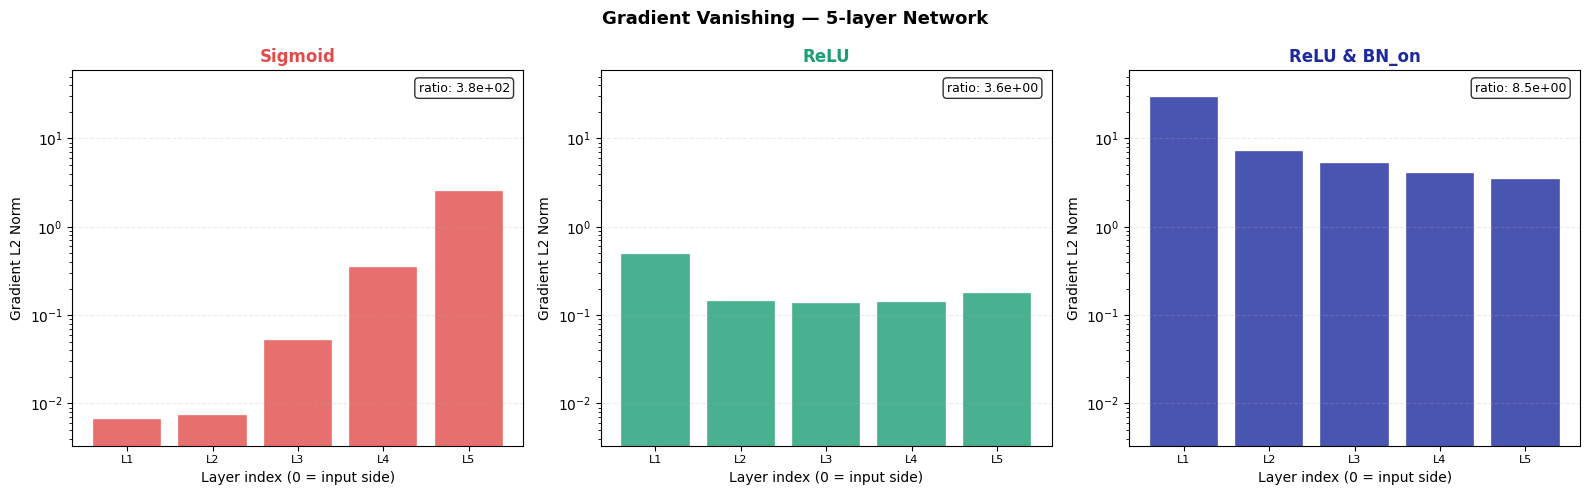

In [36]:
if __name__ == '__main__':
    torch.manual_seed(42)
    compare_depths([10, 20, 30, 50])
    plot(num_layers=5)